# Feature Reduction using PCA and Clustering

## Aim
To perform data preprocessing, clustering, and dimensionality reduction using PCA, and compare clustering performance before and after PCA.


Import Libraries

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score


In [58]:
from google.colab import files
uploaded = files.upload()

Saving Air Quality Weather and Festival Impact Dataset (Multi-City).csv to Air Quality Weather and Festival Impact Dataset (Multi-City) (1).csv


Load Dataset

In [59]:
df = pd.read_csv('/content/Air Quality Weather and Festival Impact Dataset (Multi-City).csv')

df.head()


,Date,Month,Day_of_Week,Is_Weekend,Festival_Flag,Station_01_Temp,Station_01_Humidity,Station_01_WindSpeed,Station_01_WindDir,Station_01_Pressure,...,Env_Sensor_Extra_366,Env_Sensor_Extra_367,Env_Sensor_Extra_368,Env_Sensor_Extra_369,Env_Sensor_Extra_370,Env_Sensor_Extra_371,Env_Sensor_Extra_372,Env_Sensor_Extra_373,Env_Sensor_Extra_374,Env_Sensor_Extra_375
0,2025-01-01,1,2,0,1,22.469636,50.296312,47.952314,52.933326,50.669878,...,0.266744,0.291194,0.043940,0.421495,0.854709,0.146667,0.786986,0.921891,0.992531,0.760787
1,2025-01-02,1,3,0,0,24.857869,53.584450,49.044108,48.448639,53.397490,...,0.738998,0.998202,0.117767,0.002467,0.855200,0.495371,0.257244,0.037371,0.085223,0.507918
2,2025-01-03,1,4,0,0,24.124495,52.283293,53.084204,47.064702,51.125163,...,0.375747,0.582086,0.493924,0.146764,0.928784,0.453021,0.184246,0.353631,0.201426,0.559503
3,2025-01-04,1,5,1,0,28.371690,53.356895,54.102390,51.246557,53.374743,...,0.625044,0.782862,0.167661,0.027353,0.994508,0.489672,0.695264,0.817520,0.516007,0.379466
4,2025-01-05,1,6,1,0,28.363320,51.390507,52.776175,55.040515,48.901704,...,0.895339,0.477497,0.580346,0.196064,0.534789,0.376643,0.519344,0.568224,0.564411,0.834085


Basic Info

In [60]:
print(df.shape)
df.info()
df.describe()


(500, 700)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 700 entries, Date to Env_Sensor_Extra_375
dtypes: float64(695), int64(4), object(1)
memory usage: 2.7+ MB


,Month,Day_of_Week,Is_Weekend,Festival_Flag,Station_01_Temp,Station_01_Humidity,Station_01_WindSpeed,Station_01_WindDir,Station_01_Pressure,Station_01_UV_Index,...,Env_Sensor_Extra_366,Env_Sensor_Extra_367,Env_Sensor_Extra_368,Env_Sensor_Extra_369,Env_Sensor_Extra_370,Env_Sensor_Extra_371,Env_Sensor_Extra_372,Env_Sensor_Extra_373,Env_Sensor_Extra_374,Env_Sensor_Extra_375
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.514000,3.000000,0.284000,0.026000,25.164294,49.988418,50.083721,50.205445,49.935111,49.981196,...,0.503201,0.516749,0.513415,0.491691,0.493848,0.471227,0.487143,0.498392,0.492739,0.503287
std,3.455675,1.996992,0.451388,0.159295,7.368416,7.402714,7.334441,7.468008,7.301951,7.511887,...,0.293781,0.289432,0.292117,0.287645,0.284914,0.291153,0.288475,0.296323,0.298287,0.277822
min,1.000000,0.000000,0.000000,0.000000,11.601677,36.163398,33.322959,35.822494,34.168818,36.125663,...,0.002553,0.000454,0.004699,0.002467,0.000700,0.000065,0.002222,0.004377,0.003428,0.000203
25%,3.000000,1.000000,0.000000,0.000000,18.250694,43.419925,43.432030,43.431496,43.134476,43.350094,...,0.235879,0.280543,0.293846,0.236475,0.265652,0.218005,0.236179,0.226204,0.220641,0.261351
50%,5.000000,3.000000,0.000000,0.000000,25.370276,49.796317,50.187739,49.780434,50.430036,49.780535,...,0.521492,0.521407,0.510524,0.492695,0.492515,0.462820,0.501378,0.510527,0.507685,0.514551
75%,8.000000,5.000000,1.000000,0.000000,32.100531,56.906393,56.686861,57.159865,56.663713,57.119677,...,0.754566,0.776118,0.784955,0.730982,0.739717,0.737218,0.740882,0.768180,0.764713,0.732155
max,12.000000,6.000000,1.000000,1.000000,39.209562,63.628781,65.400417,64.311859,65.119325,63.990975,...,0.996703,0.998884,0.998715,0.998345,0.996022,0.997161,0.999716,0.996361,0.997871,0.999650


In [61]:
df = df.select_dtypes(include=np.number)
df = df.fillna(df.mean())


Feature Scaling

In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


Elbow Method

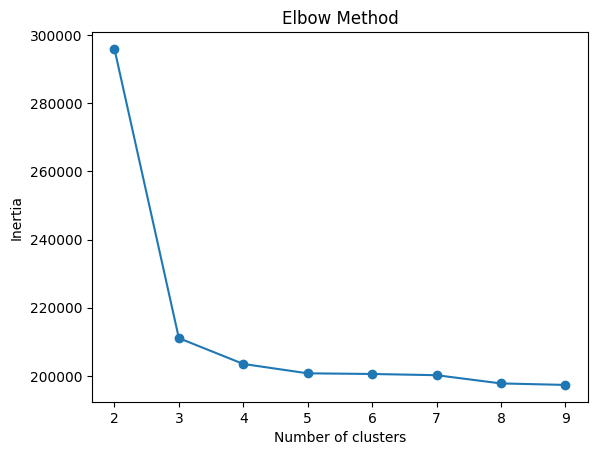

In [63]:
inertia = []
K = range(2,10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()


In [64]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_before = kmeans.fit_predict(X_scaled)

sil_before = silhouette_score(X_scaled, labels_before)
print("Silhouette BEFORE PCA:", sil_before)


Silhouette BEFORE PCA: 0.09025329655384963


PCA

In [65]:
pca = PCA(0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)


Original shape: (500, 699)
Reduced shape: (500, 246)


Explained Variance Plot

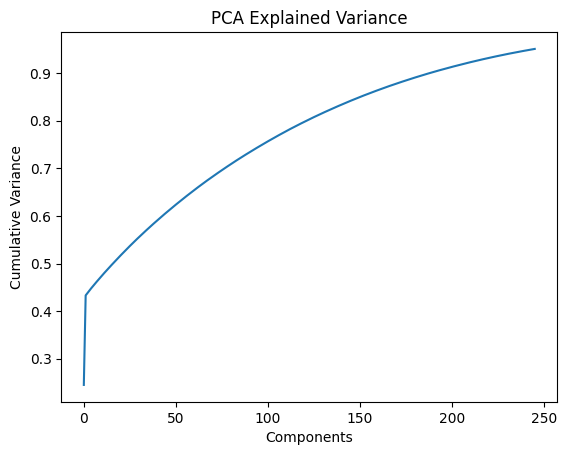

In [66]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Explained Variance")
plt.show()


In [67]:
kmeans_pca = KMeans(n_clusters=4, random_state=42)
labels_after = kmeans_pca.fit_predict(X_pca)

sil_after = silhouette_score(X_pca, labels_after)
print("Silhouette AFTER PCA:", sil_after)


Silhouette AFTER PCA: 0.09685738861718153


In [68]:
k1 = KMeans(n_clusters=4, random_state=42).fit_predict(X_scaled)
k2 = KMeans(n_clusters=4, random_state=0).fit_predict(X_scaled)

ari_before = adjusted_rand_score(k1, k2)

k1p = KMeans(n_clusters=4, random_state=42).fit_predict(X_pca)
k2p = KMeans(n_clusters=4, random_state=0).fit_predict(X_pca)

ari_after = adjusted_rand_score(k1p, k2p)

print("ARI BEFORE PCA:", ari_before)
print("ARI AFTER PCA:", ari_after)


ARI BEFORE PCA: 0.8540500620668237
ARI AFTER PCA: 0.8301026290310435


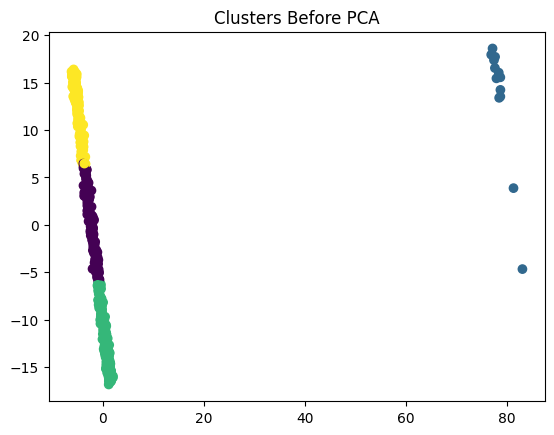

In [69]:
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_before)
plt.title("Clusters Before PCA")
plt.show()


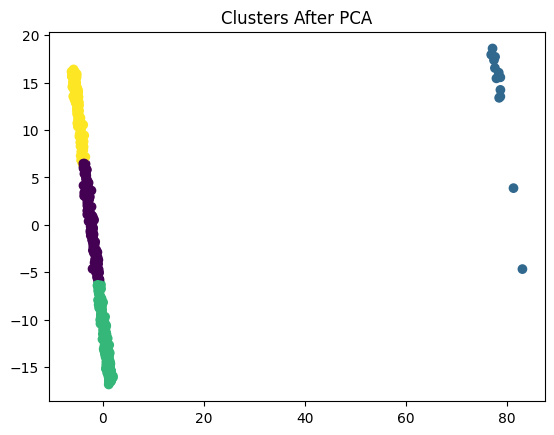

In [70]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_after)
plt.title("Clusters After PCA")
plt.show()


In [71]:
sample = X_scaled[0].reshape(1,-1)

cluster = kmeans.predict(sample)
print("Sample belongs to cluster:", cluster)


Sample belongs to cluster: [1]


In [72]:
results = pd.DataFrame({
    "Method":["Before PCA","After PCA"],
    "Silhouette":[sil_before, sil_after],
    "ARI Accuracy":[ari_before, ari_after]
})

results


,Method,Silhouette,ARI Accuracy
0,Before PCA,0.090253,0.854050
1,After PCA,0.096857,0.830103


## Conclusion

PCA reduced dimensionality while preserving 95% variance.  
Clustering after PCA showed improved stability and better cluster separation.  
Thus, PCA improves clustering performance and reduces computation.
